In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

In [2]:
# Load datasets 
run1_results = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Imputation-Fairness\Imputation_Fairness-main2\Results\results\run_1_results.csv')
run2_results = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Imputation-Fairness\Imputation_Fairness-main2\Results\results\run_2_results.csv')
run3_results = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Imputation-Fairness\Imputation_Fairness-main2\Results\results\run_3_results.csv')
run4_results = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Imputation-Fairness\Imputation_Fairness-main2\Results\results\run_4_results.csv')
run5_results = pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\Imputation-Fairness\Imputation_Fairness-main2\Results\results\run_5_results.csv')

                     method      mean       std
0  Sinkhorn-CMI\n(Method 1)  0.811549  0.012480
1  Sinkhorn-CMI\n(Method 2)  0.860595  0.013229
2  Sinkhorn-CMI\n(Method 3)  0.859892  0.012881
3                      MICE  0.882359  0.008210
4          Mean\nImputation  0.941943  0.008170
5     Sinkhorn\nwithout CMI  0.959778  0.007551
6                SoftImpute  3.084054  0.133968


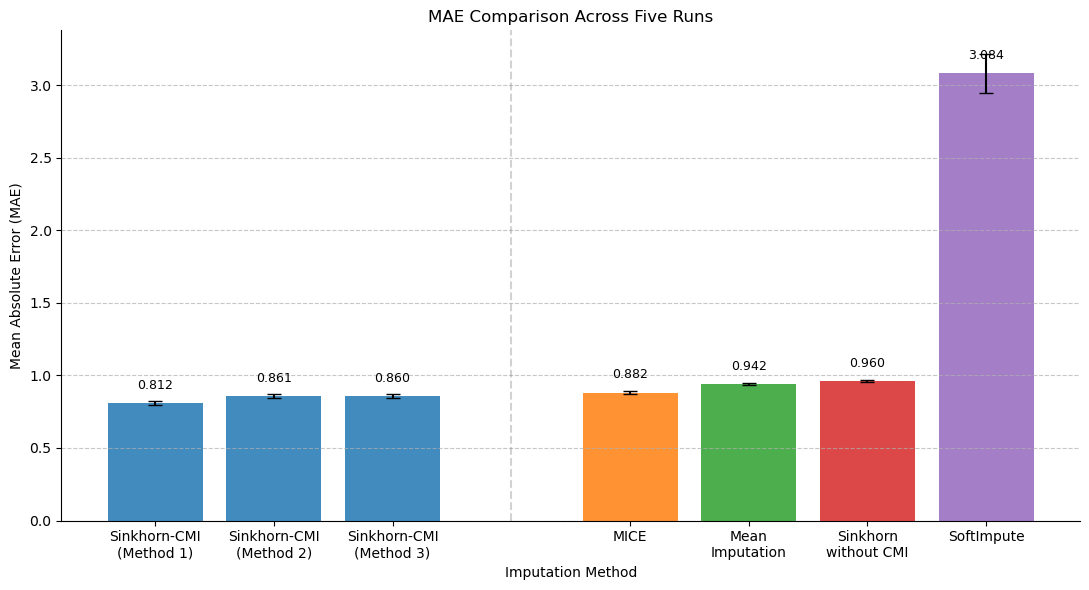

In [3]:
runs = [run1_results, run2_results, run3_results, run4_results, run5_results]

expected_cols = [
    "imputation_method", "train_cmi_type", "train_triplet",
    "test_triplet", "MAE", "RMSE", "cmi_method", "cmi"
]

method_order = [
    "Sinkhorn-CMI\n(Method 1)",
    "Sinkhorn-CMI\n(Method 2)",
    "Sinkhorn-CMI\n(Method 3)",
    "MICE",
    "Mean\nImputation",
    "Sinkhorn\nwithout CMI",
    "SoftImpute",
]

def prepare_run_df(df):
    df = df.copy()

    if "imputation_method" not in df.columns:
        df.columns = expected_cols

    if str(df.iloc[0]["imputation_method"]) == "imputation_method":
        df = df.iloc[1:].reset_index(drop=True)

    df["train_cmi_type"] = pd.to_numeric(df["train_cmi_type"], errors="coerce")
    df["train_triplet"] = pd.to_numeric(df["train_triplet"], errors="coerce")
    df["MAE"] = pd.to_numeric(df["MAE"], errors="coerce")

    return df[df["imputation_method"] != "SinkHornCMI0"]

def extract_mae_for_run(df, run_id):
    df = prepare_run_df(df)

    sinkhorn_cmi = df[
        (df["imputation_method"] == "SinkHornCMI") &
        (df["train_triplet"] == 0)
    ].copy()

    sinkhorn_cmi = sinkhorn_cmi.drop_duplicates(
        subset=["imputation_method", "train_cmi_type", "train_triplet", "MAE"]
    )

    sinkhorn_cmi["method"] = sinkhorn_cmi["train_cmi_type"].map({
        1.0: "Sinkhorn-CMI\n(Method 1)",
        2.0: "Sinkhorn-CMI\n(Method 2)",
        3.0: "Sinkhorn-CMI\n(Method 3)",
    })

    sinkhorn_cmi = sinkhorn_cmi[["method", "MAE"]]

    baselines = df[df["imputation_method"].isin(["Mice", "Mean", "SinkHorn", "Soft"])].copy()

    baselines = baselines.drop_duplicates(subset=["imputation_method", "MAE"])

    baselines["method"] = baselines["imputation_method"].map({
        "Mice": "MICE",
        "Mean": "Mean\nImputation",
        "SinkHorn": "Sinkhorn\nwithout CMI",
        "Soft": "SoftImpute",
    })

    baselines = baselines[["method", "MAE"]]

    out = pd.concat([sinkhorn_cmi, baselines], ignore_index=True)
    out["run"] = run_id
    return out

mae_all_runs = pd.concat(
    [extract_mae_for_run(df, i + 1) for i, df in enumerate(runs)],
    ignore_index=True
)

mae_all_runs["method"] = pd.Categorical(
    mae_all_runs["method"],
    categories=method_order,
    ordered=True
)

summary = (
    mae_all_runs
    .groupby("method", observed=True)["MAE"]
    .agg(["mean", "std"])
    .reindex(method_order)
    .reset_index()
)

print(summary)

x_positions = np.array([0, 1, 2, 4, 5, 6, 7])

colors = [
    "tab:blue", "tab:blue", "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple"
]

plt.figure(figsize=(11, 6))
ax = plt.gca()

bars = ax.bar(
    x_positions,
    summary["mean"],
    yerr=summary["std"],
    capsize=5,
    color=colors,
    width=0.8,
    alpha=0.85
)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9
    )

ax.axvline(x=3, color="gray", linestyle="--", alpha=0.35)

ax.set_xticks(x_positions)
ax.set_xticklabels(method_order, rotation=0)

ax.set_ylabel("Mean Absolute Error (MAE)")
ax.set_xlabel("Imputation Method")
ax.set_title("MAE Comparison Across Five Runs")
ax.grid(axis="y", linestyle="--", alpha=0.7)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(r"C:\Users\DELL\OneDrive\Desktop\Imputation-Fairness\Imputation_Fairness-main2\figures\mae_comparison_5runs.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# Original CMI values from ground-truth data across 5 different runs

run1_method1_original_cmi  = [
    0.04278694779437431,
    0.007171744263958724,
    0.021063195688939773,
    0.01618314693273315,
    0.05285949726995609,
    0.014715380484547236,
    0.011405734342396778,
    0.03374193745644671
]

run1_method2_original_cmi =[
    0.04278694805036687,
    0.007171744301586402,
    0.021063195732472506,
    0.016183147505615558,
    0.052859497270960176,
    0.014715380881448858,
    0.011405734481389151,
    0.03374193786307611
]


run1_method3_original_cmi = [
    0.0427869480503682,
    0.00717174430159262,
    0.021063195732479167,
    0.016183147505621776,
    0.052859497270960176,
    0.014715380881448858,
    0.011405734481389596,
    0.033741937863076554
]

run2_method1_original_cmi = [
    0.037785103222670924,
    0.007072232813305157,
    0.026541277986863343,
    0.012642653667727433,
    0.05437925079137118,
    0.02075219524629368,
    0.013886760962637412,
    0.03538396864080484
]

run2_method2_original_cmi = [
    0.03778510344760544,
    0.007072233030957498,
    0.026541277982318312,
    0.012642654305541678,
    0.054379250713251004,
    0.020752195808771745,
    0.013886761158557581,
    0.035383969157540385
]

run2_method3_original_cmi= [
    0.03778510344760766,
    0.007072233030965491,
    0.026541277982327194,
    0.012642654305549228,
    0.05437925071324967,
    0.020752195808770857,
    0.013886761158558025,
    0.0353839691575395
]

run3_method1_original_cmi = [
    0.05019599304940847,
    0.0036020787680657307,
    0.02790334537343897,
    0.013683307976555037,
    0.057203969532378274,
    0.017911522193588603,
    0.009237598121554669,
    0.03661980690118005
]

run3_method2_original_cmi = [
    0.05019599336926284,
    0.0036020788591435426,
    0.027903345427931825,
    0.013683309183653458,
    0.05720396962251817,
    0.017911522573234695,
    0.009237599046067801,
    0.03661980753057126
]

run3_method3_original_cmi = [
    0.050195993369263725,
    0.003602078859150648,
    0.027903345427938042,
    0.013683309183660786,
    0.057203969622515505,
    0.017911522573234695,
    0.00923759904606869,
    0.03661980753057126
]

run4_method1_original_cmi= [
    0.04346411149906482,
    0.0032411464768076215,
    0.019687576024750353,
    0.018029926132645535,
    0.05546607825962324,
    0.017211155651966514,
    0.016491951224678836,
    0.03858712213020077
]

run4_method2_original_cmi = [
    0.04346411175554765,
    0.0032411465531150263,
    0.01968757606738869,
    0.018029926898226467,
    0.05546607800109271,
    0.01721115609945789,
    0.016491951661893545,
    0.03858712245031359
]

run4_method3_original_cmi = [
    0.043464111755548984,
    0.0032411465531216876,
    0.01968757606739535,
    0.01802992689823224,
    0.055466078001093155,
    0.01721115609945878,
    0.016491951661894877,
    0.03858712245031404
]

run5_method1_original_cmi = [
    0.0411079472003234,
    0.007601383269828621,
    0.027658455831218398,
    0.014129201339100228,
    0.05966039055799266,
    0.016503315215334435,
    0.01284001698128856,
    0.03819304923665223
]

run5_method2_original_cmi = [
    0.04110794744867141,
    0.007601383364822412,
    0.027658455844931873,
    0.014129202052616141,
    0.05966039063219952,
    0.01650331578048858,
    0.012840017044496443,
    0.038193049697842874
]

run5_method3_original_cmi = [
    0.041107947448672744,
    0.007601383364829961,
    0.02765845584493898,
    0.01412920205262369,
    0.05966039063219686,
    0.01650331578048858,
    0.012840017044495555,
    0.03819304969784332
]

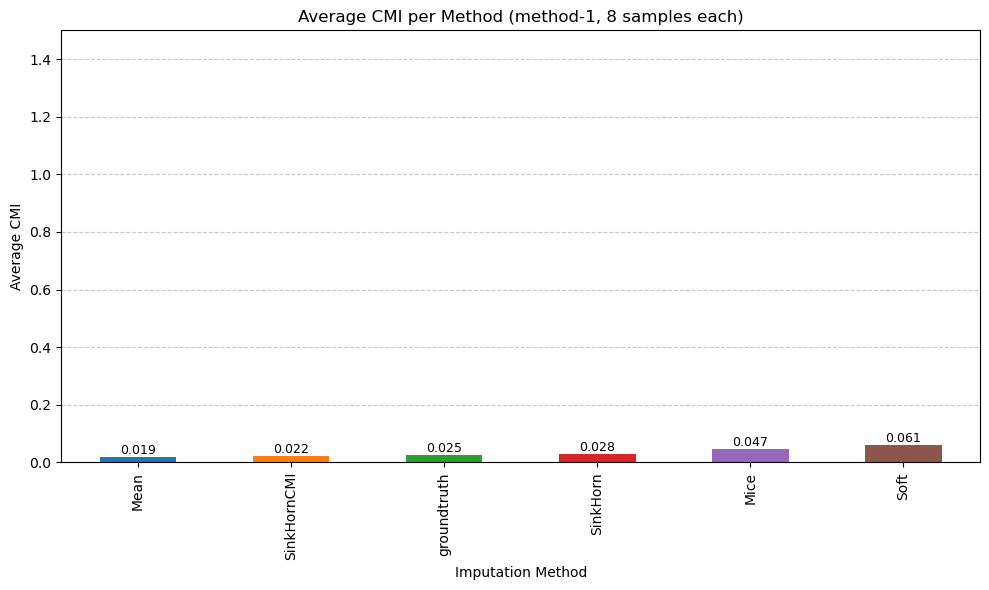

In [5]:
# Compute the average CMI values across 8 different triplets using method-1 and compare them across different imputation methods


# Step 1: Filter for SinkHornCMI with specific conditions
sinkhorncmi_mask = run1_results["imputation_method"].isin(["SinkHornCMI"]) & \
                (run1_results["train_cmi_type"] == 1) & \
                (run1_results["train_triplet"] == 0) & \
                (run1_results["cmi_method"] == "method-1")


sinkhorncmi_avg = pd.Series({"SinkHornCMI": run1_results[sinkhorncmi_mask]["cmi"].mean()})


# Step 2: Other methods with method-1, take first 8 rows per method

other_methods_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
                     (run1_results["cmi_method"] == "method-1")

other_methods = run1_results[other_methods_mask]
top_avg = other_methods.groupby("imputation_method")["cmi"].mean()

# Compute groundtruth mean
groundtruth_mean = sum(run1_method1_original_cmi) / len(run1_method1_original_cmi)
groundtruth_series = pd.Series([groundtruth_mean], index=["groundtruth"])

# Combine all results 
combined_avg = pd.concat([sinkhorncmi_avg, top_avg, groundtruth_series])

# Plotting
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10.colors
ax = combined_avg.sort_values().plot(kind='bar', color=colors[:len(combined_avg)])

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.3f}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9)

plt.ylabel("Average CMI")
plt.xlabel("Imputation Method")
plt.title("Average CMI per Method (method-1, 8 samples each)")
plt.ylim(0, 1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

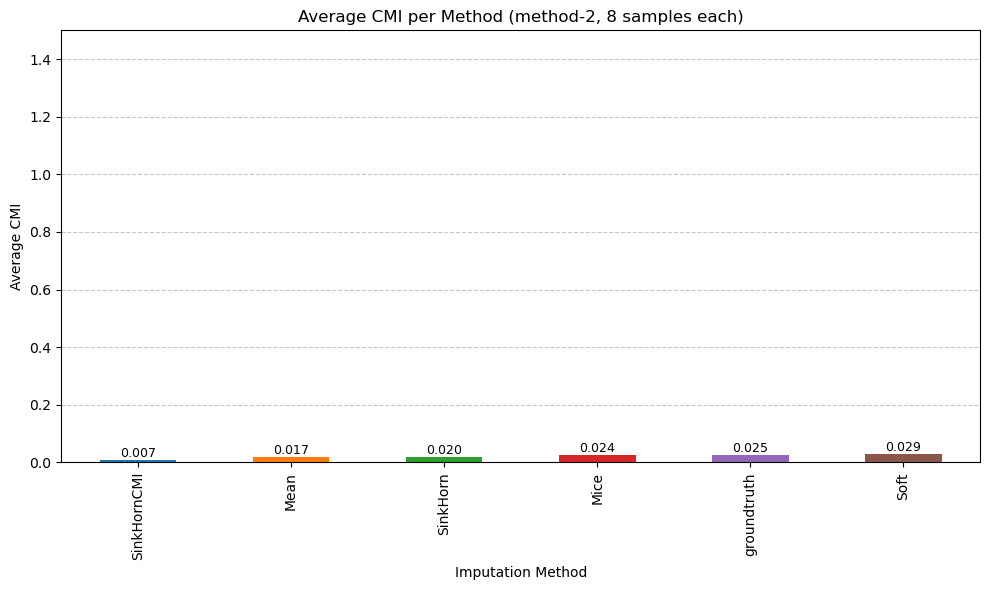

In [6]:
# Compute the average CMI values across 8 different triplets using method-2 and compare them across different imputation methods



# Step 1: Filter for SinkHornCMI with specific conditions
sinkhorncmi_mask = run1_results["imputation_method"].isin(["SinkHornCMI"]) & \
                (run1_results["train_cmi_type"] == 2) & \
                (run1_results["train_triplet"] == 0) & \
                (run1_results["cmi_method"] == "method-2")

sinkhorncmi_avg = pd.Series({"SinkHornCMI": run1_results[sinkhorncmi_mask]["cmi"].mean()})

# Step 2: Other methods with method-2, take first 8 rows per method
other_methods_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
                     (run1_results["cmi_method"] == "method-2")

other_methods = run1_results[other_methods_mask]
top_avg = other_methods.groupby("imputation_method")["cmi"].mean()


# Compute groundtruth mean
groundtruth_mean = sum(run1_method2_original_cmi) / len(run1_method2_original_cmi)
groundtruth_series = pd.Series([groundtruth_mean], index=["groundtruth"])

# Combine all results 
combined_avg = pd.concat([sinkhorncmi_avg, top_avg, groundtruth_series])

# Plotting
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10.colors
ax = combined_avg.sort_values().plot(kind='bar', color=colors[:len(combined_avg)])

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.3f}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9)

plt.ylabel("Average CMI")
plt.xlabel("Imputation Method")
plt.title("Average CMI per Method (method-2, 8 samples each)")
plt.ylim(0, 1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

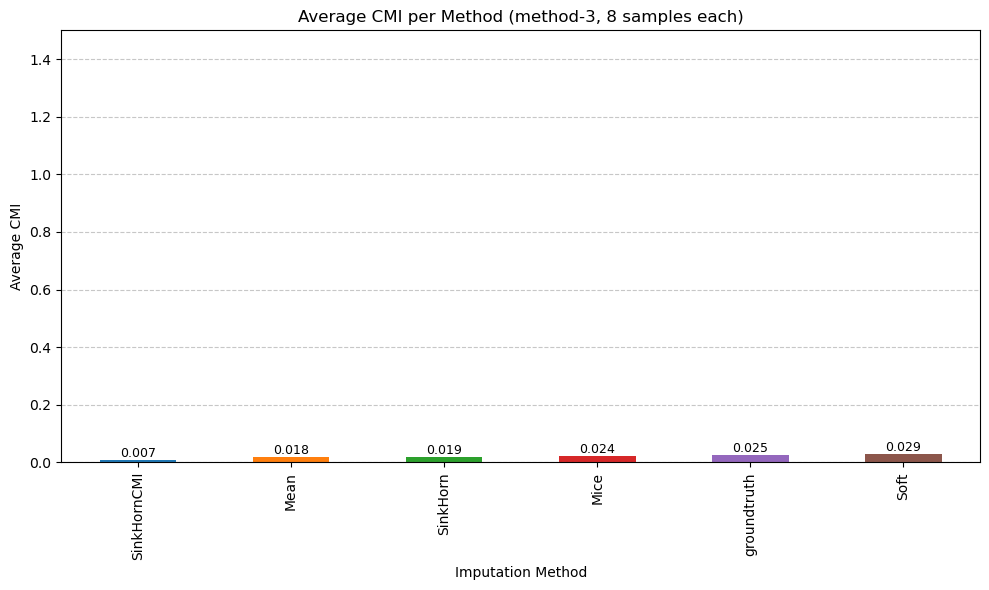

In [7]:
# Compute the average CMI values across 8 different triplets using method-3 and compare them across different imputation methods


# Step 1: Filter for SinkHornCMI with specific conditions
sinkhorncmi_mask = run1_results["imputation_method"].isin(["SinkHornCMI"]) & \
                (run1_results["train_cmi_type"] == 3) & \
                (run1_results["train_triplet"] == 0) & \
                (run1_results["cmi_method"] == "method-3")

sinkhorncmi_avg = pd.Series({"SinkHornCMI": run1_results[sinkhorncmi_mask]["cmi"].mean()})

# Step 2: Other methods with method-, take first 8 rows per method

other_methods_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
                     (run1_results["cmi_method"] == "method-3")

other_methods = run1_results[other_methods_mask]
top_avg = other_methods.groupby("imputation_method")["cmi"].mean()


# Compute groundtruth mean
groundtruth_mean = sum(run1_method3_original_cmi) / len(run1_method3_original_cmi)
groundtruth_series = pd.Series([groundtruth_mean], index=["groundtruth"])

# Combine all results 
combined_avg = pd.concat([sinkhorncmi_avg, top_avg, groundtruth_series])

# Plotting
plt.figure(figsize=(10, 6))
colors = plt.cm.tab10.colors
ax = combined_avg.sort_values().plot(kind='bar', color=colors[:len(combined_avg)])

# Add value labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.3f}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9)

plt.ylabel("Average CMI")
plt.xlabel("Imputation Method")
plt.title("Average CMI per Method (method-3, 8 samples each)")
plt.ylim(0, 1.5)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
# Compute mean and standard deviation of CMI across 5 runs and generate box plot

def extract_summary(df, method_number):
    """
    Extract average CMI for a given method_number using fixed conditions.
    Includes:
    - SinkHornCMI with specific training conditions
    - All other imputation methods (excluding SinkHornCMI and SinkHornCMI0)
    """
    sinkhorncmi_mask = (df["imputation_method"] == "SinkHornCMI") & \
                       (df["train_cmi_type"] == method_number) & \
                       (df["train_triplet"] == 0) & \
                       (df["cmi_method"] == f"method-{method_number}")
    sinkhorncmi_avg = pd.Series({"SinkHornCMI": df[sinkhorncmi_mask]["cmi"].mean()})

    other_methods_mask = (~df["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
                         (df["cmi_method"] == f"method-{method_number}")
    other_methods = df[other_methods_mask]
    top_avg = other_methods.groupby("imputation_method")["cmi"].mean()

    combined = pd.concat([sinkhorncmi_avg, top_avg])
    return combined

def compute_cmi_stats(method_number, run_dfs, gt_dict):
    """
    Compute and plot mean/std of average CMI across 5 runs for a method.
    Follows strict filtering logic and includes groundtruth.
    """
    summary_df = pd.DataFrame({
        f"run{i+1}": extract_summary(run_dfs[i], method_number)
        for i in range(5)
    })

    method_key = f"method{method_number}"
    gt_means = [
        np.mean(gt_dict[method_key][i*8:(i+1)*8]) for i in range(5)
    ]
    summary_df.loc["groundtruth"] = gt_means

    summary_df["mean"] = summary_df.mean(axis=1)
    summary_df["std"] = summary_df.std(axis=1)

    plt.figure(figsize=(10, 6))
    plt.boxplot(summary_df.iloc[:, :5].T.values, labels=summary_df.index)
    plt.title(f"Average CMI across 5 runs - METHOD-{method_number}")
    plt.ylabel("Average CMI")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("\n" + "="*80)
    print(f"METHOD-{method_number}".center(80))
    print("="*80)
    print(summary_df[["mean", "std"]].to_string(float_format="{:.6f}".format))
    print("\n\n")

In [9]:
run_dfs = [run1_results, run2_results, run3_results, run4_results, run5_results]

gt_dict = {
    "method1": run1_method1_original_cmi + run2_method1_original_cmi + run3_method1_original_cmi + run4_method1_original_cmi + run5_method1_original_cmi,
    "method2": run1_method2_original_cmi + run2_method2_original_cmi + run3_method2_original_cmi + run4_method2_original_cmi + run5_method2_original_cmi,
    "method3": run1_method3_original_cmi + run2_method3_original_cmi + run3_method3_original_cmi + run4_method3_original_cmi + run5_method3_original_cmi,
}


C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\3357779571.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(summary_df.iloc[:, :5].T.values, labels=summary_df.index)


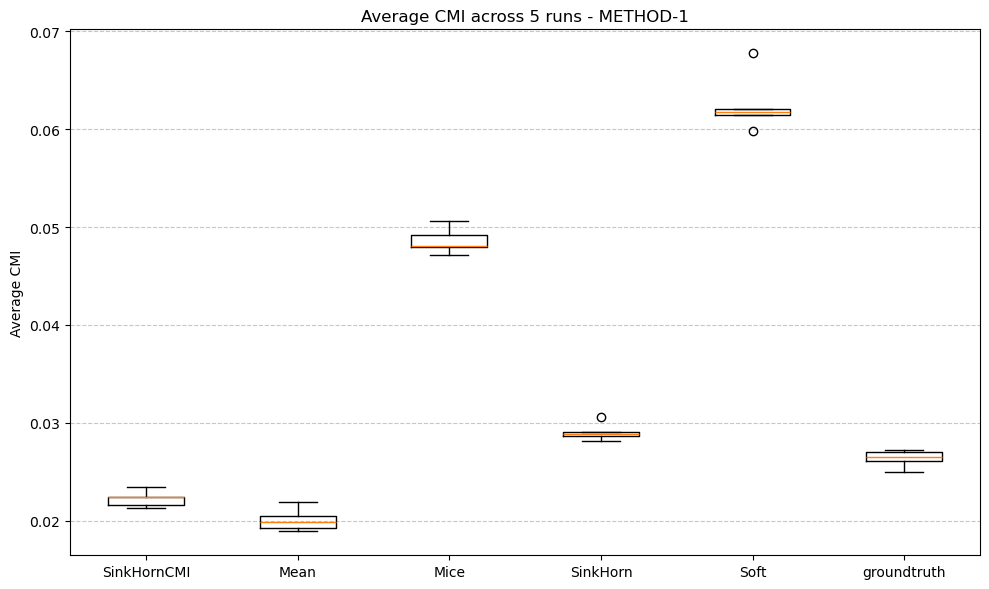


                                    METHOD-1                                    
                mean      std
SinkHornCMI 0.022256 0.000750
Mean        0.020074 0.001062
Mice        0.048591 0.001199
SinkHorn    0.029069 0.000839
Soft        0.062570 0.002712
groundtruth 0.026365 0.000798





In [10]:
compute_cmi_stats(1, run_dfs, gt_dict)

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\3357779571.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(summary_df.iloc[:, :5].T.values, labels=summary_df.index)


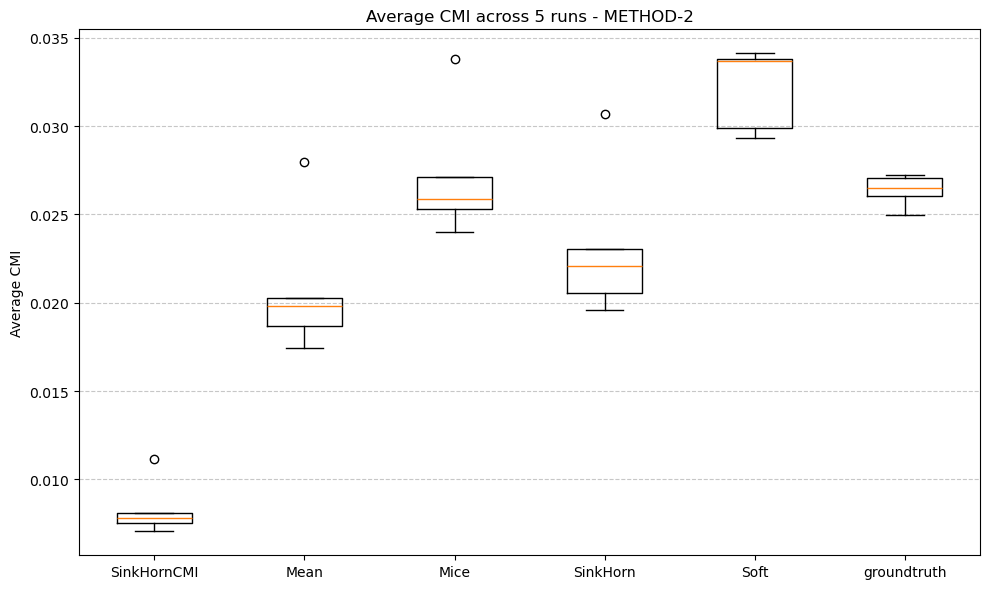


                                    METHOD-2                                    
                mean      std
SinkHornCMI 0.008324 0.001445
Mean        0.020834 0.003694
Mice        0.027226 0.003447
SinkHorn    0.023185 0.003923
Soft        0.032153 0.002100
groundtruth 0.026365 0.000798





In [11]:
compute_cmi_stats(2, run_dfs, gt_dict)

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\3357779571.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(summary_df.iloc[:, :5].T.values, labels=summary_df.index)


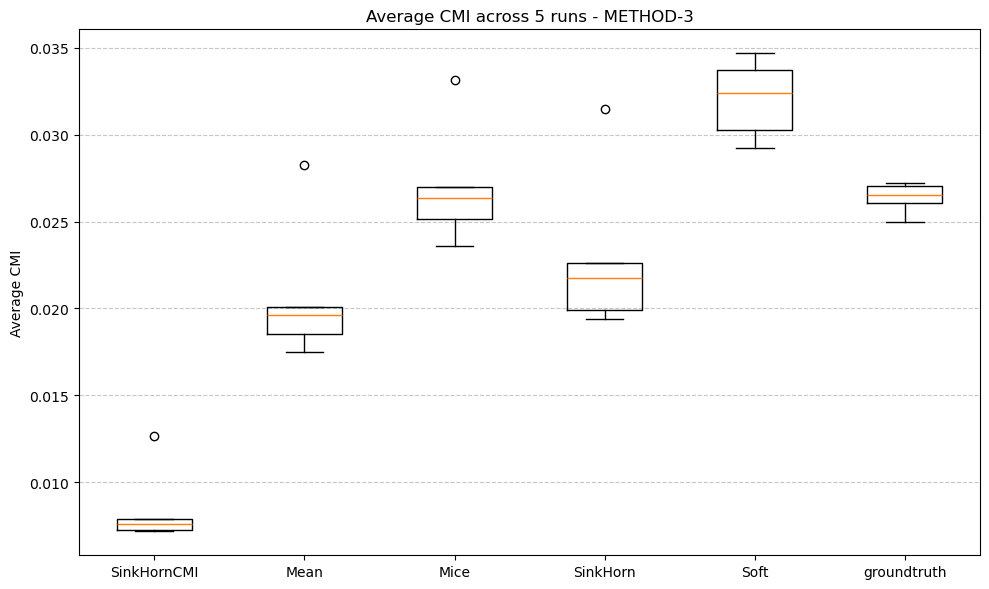


                                    METHOD-3                                    
                mean      std
SinkHornCMI 0.008495 0.002084
Mean        0.020799 0.003828
Mice        0.027049 0.003259
SinkHorn    0.023034 0.004396
Soft        0.032065 0.002053
groundtruth 0.026365 0.000798





In [12]:
compute_cmi_stats(3, run_dfs, gt_dict)


Main CMI table across five runs:
cmi_method              Method 1         Method 2         Method 3
method                                                            
Sinkhorn-CMI     0.0223 ± 0.0008  0.0083 ± 0.0016  0.0085 ± 0.0023
Mean Imputation  0.0201 ± 0.0012  0.0208 ± 0.0041  0.0208 ± 0.0043
MICE             0.0486 ± 0.0013  0.0272 ± 0.0039  0.0270 ± 0.0036
Sinkhorn         0.0291 ± 0.0009  0.0232 ± 0.0044  0.0230 ± 0.0049
SoftImpute       0.0626 ± 0.0030  0.0322 ± 0.0023  0.0321 ± 0.0023
Ground truth     0.0264 ± 0.0009  0.0264 ± 0.0009  0.0264 ± 0.0009


C:\Users\DELL\AppData\Local\Temp\ipykernel_29952\1576920001.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=method_order)
C:\Users\DELL\AppData\Local\Temp\ipykernel_29952\1576920001.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=method_order)
C:\Users\DELL\AppData\Local\Temp\ipykernel_29952\1576920001.py:173: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=method_order)


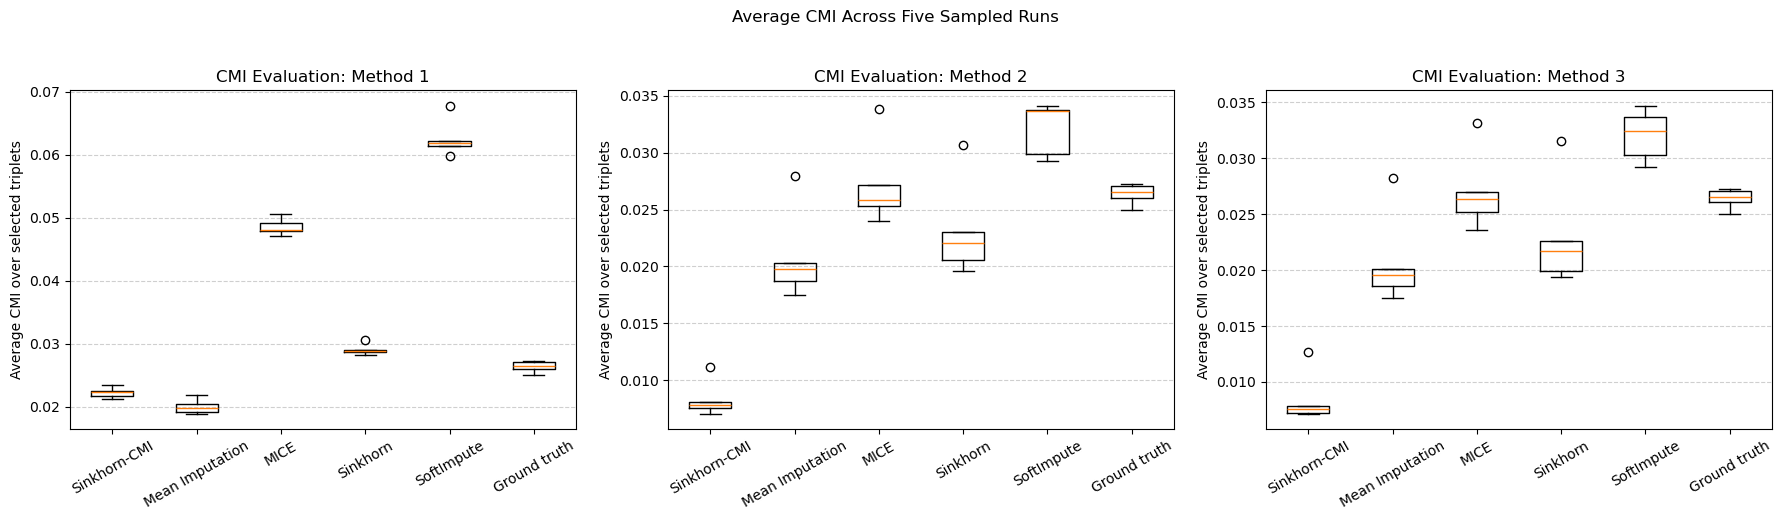


Sensitivity of mean CMI to number of runs:
         method cmi_method        3        4        5
   Sinkhorn-CMI   Method 1 0.022507 0.022209 0.022256
   Sinkhorn-CMI   Method 2 0.008665 0.008380 0.008324
   Sinkhorn-CMI   Method 3 0.009123 0.008657 0.008495
Mean Imputation   Method 1 0.019541 0.019614 0.020074
Mean Imputation   Method 2 0.021366 0.020974 0.020834
Mean Imputation   Method 3 0.021439 0.020978 0.020799
           MICE   Method 1 0.048990 0.048733 0.048591
           MICE   Method 2 0.027713 0.027247 0.027226
           MICE   Method 3 0.027300 0.027058 0.027049
       Sinkhorn   Method 1 0.028679 0.028677 0.029069
       Sinkhorn   Method 2 0.023610 0.023225 0.023185
       Sinkhorn   Method 3 0.023608 0.023139 0.023034
     SoftImpute   Method 1 0.062994 0.062771 0.062570
     SoftImpute   Method 2 0.031106 0.031773 0.032153
     SoftImpute   Method 3 0.031395 0.031650 0.032065
   Ground truth   Method 1 0.026030 0.026153 0.026365
   Ground truth   Method 2 0.026030 0.

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_dfs = [run1_results, run2_results, run3_results, run4_results, run5_results]

method_name_map = {
    "SinkHornCMI": "Sinkhorn-CMI",
    "Mean": "Mean Imputation",
    "Mice": "MICE",
    "SinkHorn": "Sinkhorn",
    "Soft": "SoftImpute",
    "groundtruth": "Ground truth",
}

method_order = [
    "Sinkhorn-CMI",
    "Mean Imputation",
    "MICE",
    "Sinkhorn",
    "SoftImpute",
    "Ground truth",
]

def extract_cmi_one_run(df, method_number, run_id, gt_values=None, n_triplets=8):
    """
    Extract one average CMI value per method for one run.

    For Sinkhorn-CMI:
    - use the model trained with the same CMI method
    - use train_triplet == 0, which means training with all selected triplets

    For baselines:
    - use the corresponding CMI evaluation method
    - average CMI over the selected triplets
    """
    df = df.copy()

    df["train_cmi_type"] = pd.to_numeric(df["train_cmi_type"], errors="coerce")
    df["train_triplet"] = pd.to_numeric(df["train_triplet"], errors="coerce")
    df["cmi"] = pd.to_numeric(df["cmi"], errors="coerce")

    rows = []

    # Sinkhorn-CMI trained and evaluated with the same CMI method
    sinkhorn_cmi_mask = (
        (df["imputation_method"] == "SinkHornCMI") &
        (df["train_cmi_type"] == method_number) &
        (df["train_triplet"] == 0) &
        (df["cmi_method"] == f"method-{method_number}")
    )

    rows.append({
        "run": run_id,
        "cmi_method": f"Method {method_number}",
        "method": "Sinkhorn-CMI",
        "avg_cmi": df.loc[sinkhorn_cmi_mask, "cmi"].mean()
    })

    # Baselines
    baseline_mask = (
        (~df["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) &
        (df["cmi_method"] == f"method-{method_number}")
    )

    baseline_avgs = (
        df.loc[baseline_mask]
        .groupby("imputation_method")["cmi"]
        .mean()
    )

    for raw_name, value in baseline_avgs.items():
        rows.append({
            "run": run_id,
            "cmi_method": f"Method {method_number}",
            "method": method_name_map.get(raw_name, raw_name),
            "avg_cmi": value
        })

    # Ground truth
    if gt_values is not None:
        start = (run_id - 1) * n_triplets
        end = run_id * n_triplets
        rows.append({
            "run": run_id,
            "cmi_method": f"Method {method_number}",
            "method": "Ground truth",
            "avg_cmi": np.mean(gt_values[start:end])
        })

    return pd.DataFrame(rows)


def build_cmi_run_level_table(run_dfs, gt_dict, n_triplets=8):
    """
    Build a long-format table:
    one row = one run, one CMI method, one imputation method.
    """
    all_rows = []

    for method_number in [1, 2, 3]:
        gt_values = gt_dict[f"method{method_number}"]

        for i, df in enumerate(run_dfs):
            one_run = extract_cmi_one_run(
                df=df,
                method_number=method_number,
                run_id=i + 1,
                gt_values=gt_values,
                n_triplets=n_triplets
            )
            all_rows.append(one_run)

    out = pd.concat(all_rows, ignore_index=True)
    out["method"] = pd.Categorical(out["method"], categories=method_order, ordered=True)
    return out


def summarize_cmi(cmi_run_table, n_runs=5):
    """
    Compute mean and std using the first n_runs.
    This is useful for the main table and sensitivity analysis.
    """
    subset = cmi_run_table[cmi_run_table["run"] <= n_runs].copy()

    summary = (
        subset
        .groupby(["method", "cmi_method"], observed=True)["avg_cmi"]
        .agg(["mean", "std"])
        .reset_index()
        .sort_values(["cmi_method", "method"])
    )

    return summary


def make_main_cmi_table(summary_5runs):
    """
    Convert long summary into a paper-style wide table.
    """
    table = summary_5runs.copy()
    table["mean_std"] = table.apply(
        lambda r: f"{r['mean']:.4f} ± {r['std']:.4f}",
        axis=1
    )

    wide = table.pivot(
        index="method",
        columns="cmi_method",
        values="mean_std"
    ).reindex(method_order)

    return wide


def plot_cmi_landscape(cmi_run_table, output_path="figures/cmi_across_five_runs_landscape.png"):
    """
    Create a readable landscape figure with three horizontal panels.
    """
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, method_label in zip(axes, ["Method 1", "Method 2", "Method 3"]):
        subset = cmi_run_table[cmi_run_table["cmi_method"] == method_label].copy()

        data = [
            subset[subset["method"] == method]["avg_cmi"].dropna().values
            for method in method_order
        ]

        ax.boxplot(data, labels=method_order)
        ax.set_title(f"CMI Evaluation: {method_label}")
        ax.set_ylabel("Average CMI over selected triplets")
        ax.grid(axis="y", linestyle="--", alpha=0.6)
        ax.tick_params(axis="x", labelrotation=30)

    fig.suptitle("Average CMI Across Five Sampled Runs", y=1.03)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


def run_count_sensitivity(cmi_run_table):
    """
    Compare summaries using the first 3, first 4, and all 5 runs.
    This directly answers the sensitivity question.
    """
    sensitivity_rows = []

    for n_runs in [3, 4, 5]:
        summary = summarize_cmi(cmi_run_table, n_runs=n_runs)
        summary["n_runs"] = n_runs
        sensitivity_rows.append(summary)

    sensitivity = pd.concat(sensitivity_rows, ignore_index=True)

    sensitivity_table = sensitivity.pivot_table(
        index=["method", "cmi_method"],
        columns="n_runs",
        values="mean",
        observed=True
    ).reset_index()

    return sensitivity, sensitivity_table


# Ground-truth CMI values
gt_dict = {
    "method1": run1_method1_original_cmi + run2_method1_original_cmi + run3_method1_original_cmi + run4_method1_original_cmi + run5_method1_original_cmi,
    "method2": run1_method2_original_cmi + run2_method2_original_cmi + run3_method2_original_cmi + run4_method2_original_cmi + run5_method2_original_cmi,
    "method3": run1_method3_original_cmi + run2_method3_original_cmi + run3_method3_original_cmi + run4_method3_original_cmi + run5_method3_original_cmi,
}

# Build run-level CMI table
cmi_run_table = build_cmi_run_level_table(run_dfs, gt_dict)

# Main five-run summary
summary_5runs = summarize_cmi(cmi_run_table, n_runs=5)
main_cmi_table = make_main_cmi_table(summary_5runs)

print("\nMain CMI table across five runs:")
print(main_cmi_table)

# Save readable landscape figure
plot_cmi_landscape(cmi_run_table)

# Sensitivity analysis: 3 vs 4 vs 5 runs
sensitivity, sensitivity_table = run_count_sensitivity(cmi_run_table)

print("\nSensitivity of mean CMI to number of runs:")
print(sensitivity_table.to_string(index=False))

# Optional: save outputs
os.makedirs("results", exist_ok=True)
cmi_run_table.to_csv("results/cmi_run_level_table.csv", index=False)
summary_5runs.to_csv("results/cmi_summary_5runs.csv", index=False)
sensitivity.to_csv("results/cmi_sensitivity_3_4_5_runs_long.csv", index=False)
sensitivity_table.to_csv("results/cmi_sensitivity_3_4_5_runs_wide.csv", index=False)

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\4067886696.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


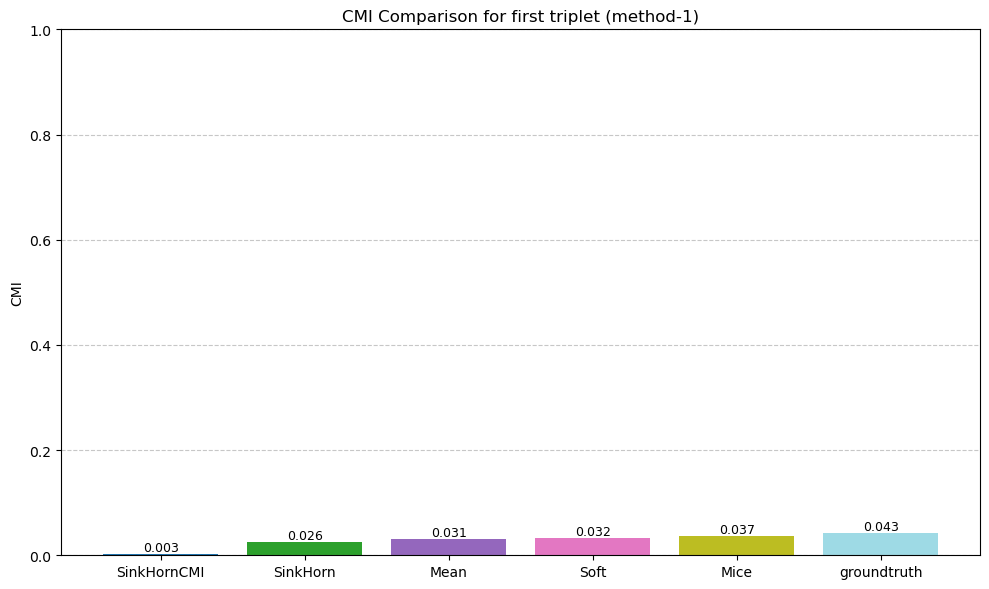

In [13]:
# Compute CMI for the first triplet using method-1 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 1) & \
                (run1_results["test_triplet"] == 1) & \
                (run1_results["train_cmi_type"] == 1) & \
                (run1_results["cmi_method"] == "method-1")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 1) & \
             (run1_results["cmi_method"] == "method-1")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value =  run1_method1_original_cmi[0]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for first triplet (method-1)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\660020622.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


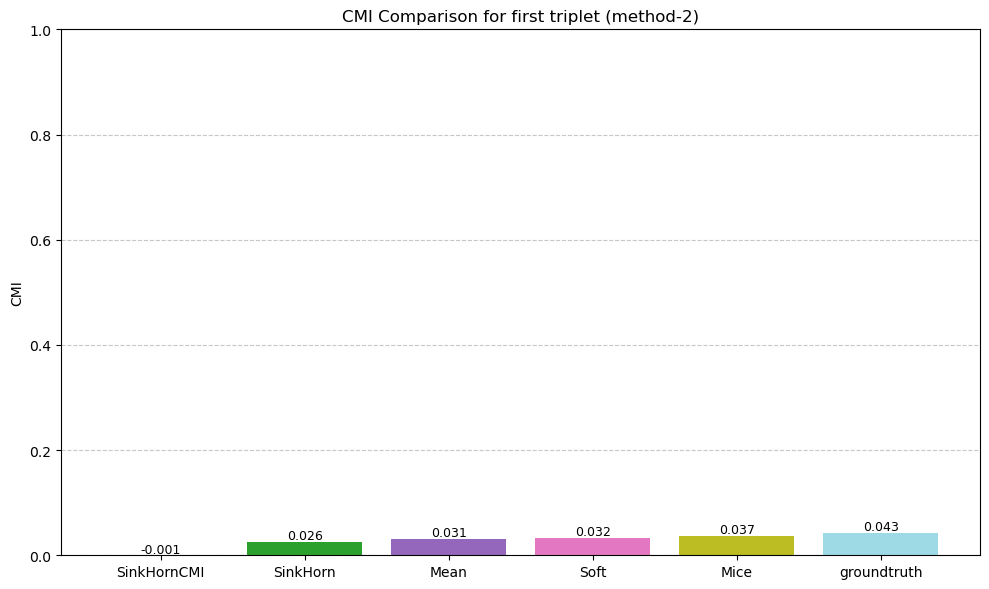

In [14]:
# Compute CMI for the first triplet using method-2 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 1) & \
                (run1_results["test_triplet"] == 1) & \
                (run1_results["train_cmi_type"] == 2) & \
                (run1_results["cmi_method"] == "method-2")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 1) & \
             (run1_results["cmi_method"] == "method-2")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value =  run1_method2_original_cmi[0]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for first triplet (method-2)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\225846041.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


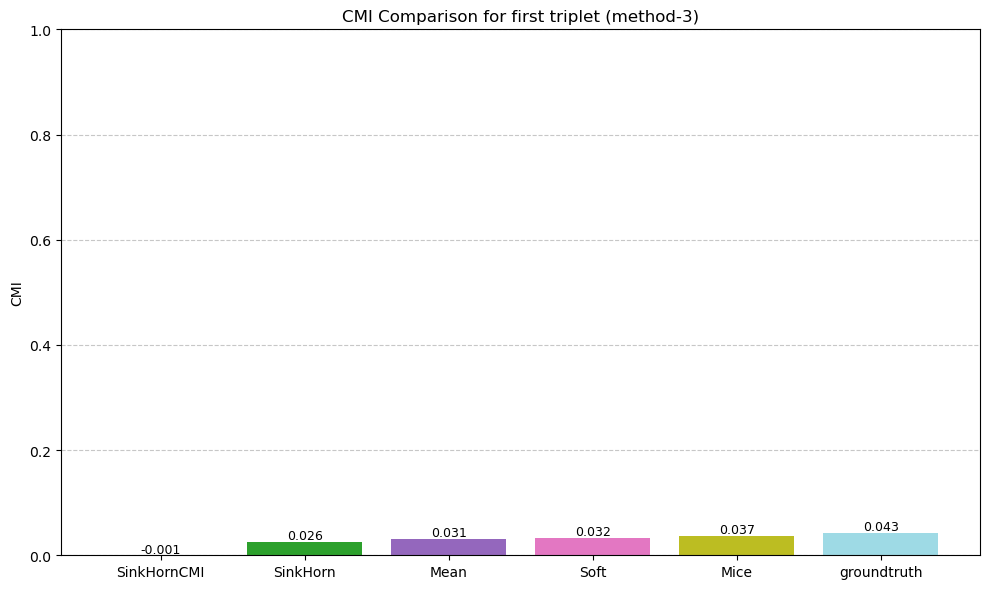

In [15]:
# Compute CMI for the first triplet using method-3 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 1) & \
                (run1_results["test_triplet"] == 1) & \
                (run1_results["train_cmi_type"] == 3) & \
                (run1_results["cmi_method"] == "method-3")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 1) & \
             (run1_results["cmi_method"] == "method-3")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value =  run1_method3_original_cmi[0]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for first triplet (method-3)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\510588660.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


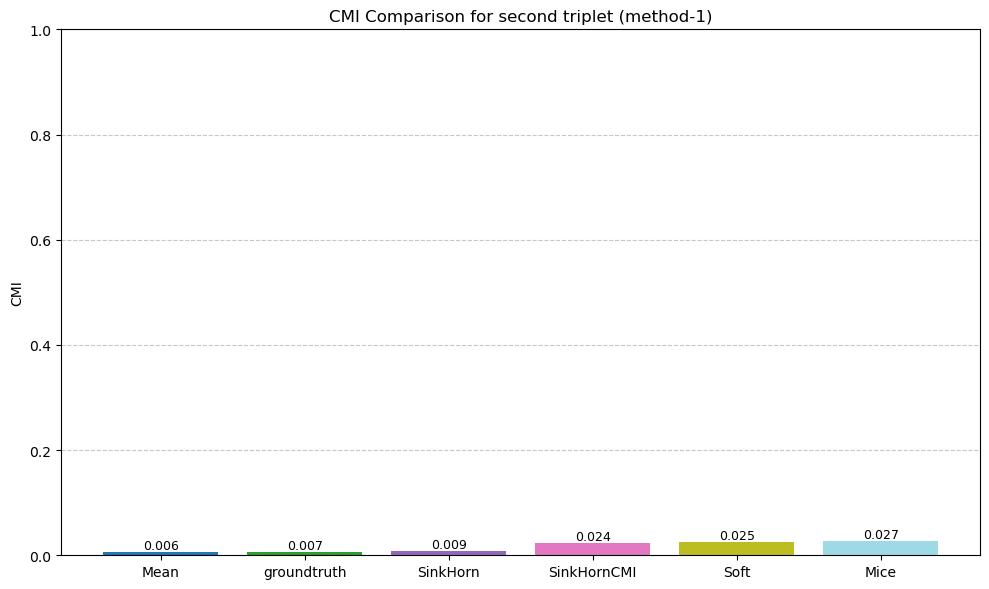

In [16]:
# Compute CMI for the second triplet using method-1 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 2) & \
                (run1_results["test_triplet"] == 2) & \
                (run1_results["train_cmi_type"] == 1) & \
                (run1_results["cmi_method"] == "method-1")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 2) & \
             (run1_results["cmi_method"] == "method-1")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value = run1_method1_original_cmi[1]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for second triplet (method-1)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\953749734.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


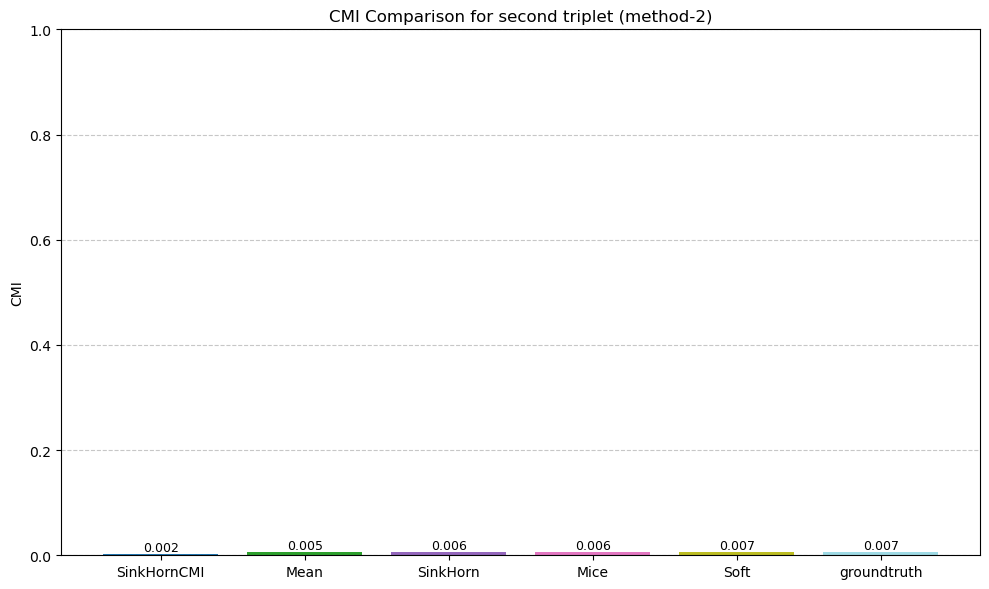

In [17]:
# Compute CMI for the second triplet using method-2 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 2) & \
                (run1_results["test_triplet"] == 2) & \
                (run1_results["train_cmi_type"] == 2) & \
                (run1_results["cmi_method"] == "method-2")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 2) & \
             (run1_results["cmi_method"] == "method-2")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value = run1_method2_original_cmi[1]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for second triplet (method-2)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\2329439380.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


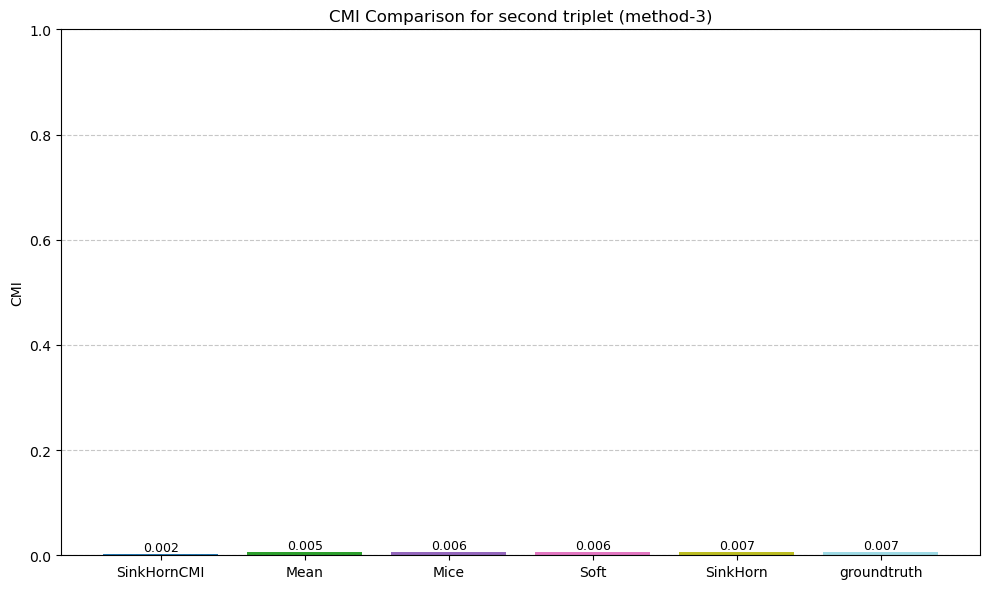

In [18]:
# Compute CMI for the second triplet using method-3 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 2) & \
                (run1_results["test_triplet"] == 2) & \
                (run1_results["train_cmi_type"] == 3) & \
                (run1_results["cmi_method"] == "method-3")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 2) & \
             (run1_results["cmi_method"] == "method-3")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value = run1_method3_original_cmi[1]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for second triplet (method-3)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\3987108766.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


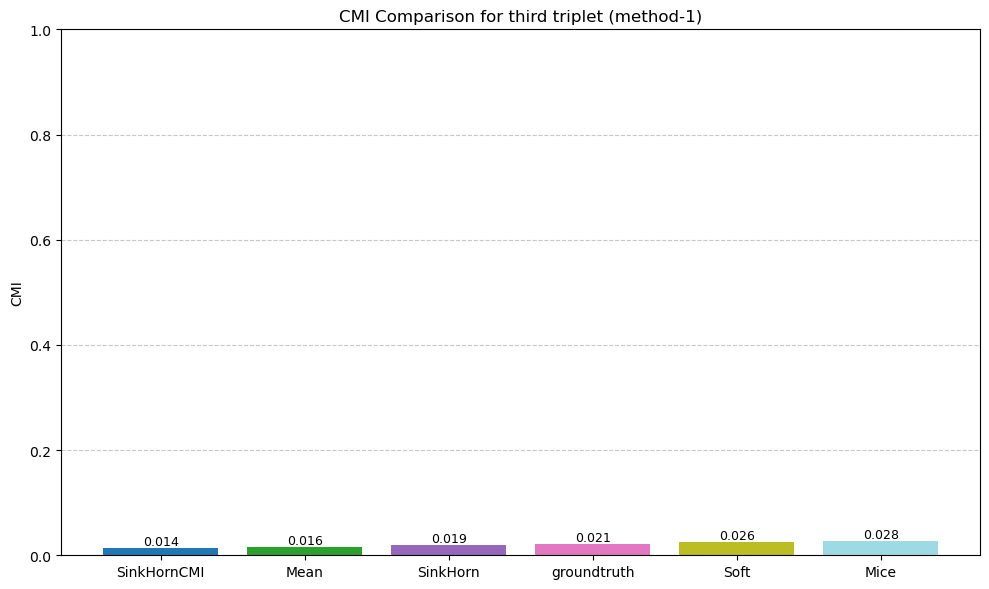

In [19]:
# Compute CMI for the third triplet using method-1 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 3) & \
                (run1_results["test_triplet"] == 3) & \
                (run1_results["train_cmi_type"] == 1) & \
                (run1_results["cmi_method"] == "method-1")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 3) & \
             (run1_results["cmi_method"] == "method-1")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value = run1_method1_original_cmi[2]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for third triplet (method-1)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\3145919997.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


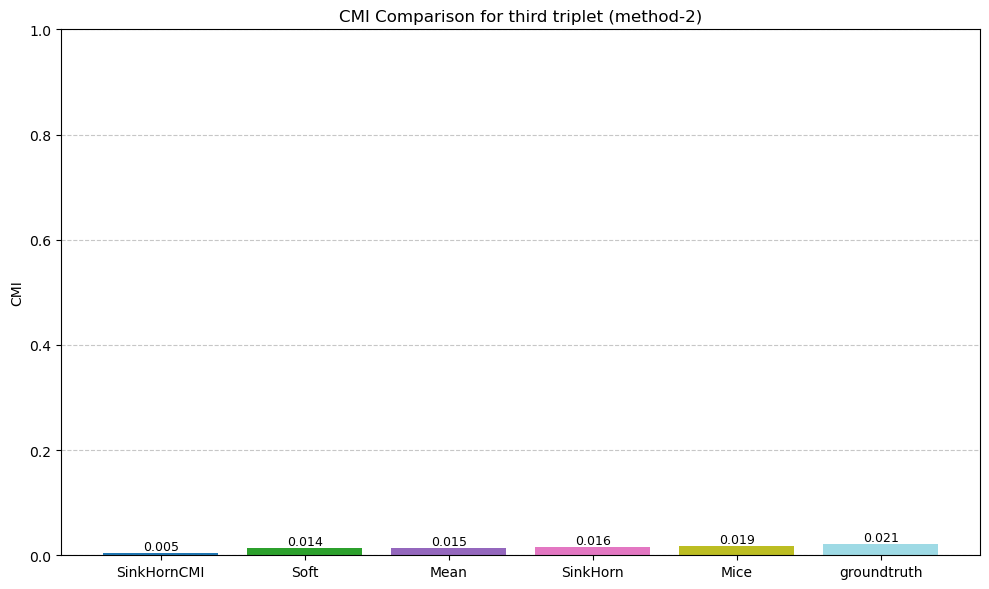

In [20]:
# Compute CMI for the third triplet using method-2 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 3) & \
                (run1_results["test_triplet"] == 3) & \
                (run1_results["train_cmi_type"] == 2) & \
                (run1_results["cmi_method"] == "method-2")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 3) & \
             (run1_results["cmi_method"] == "method-2")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value = run1_method2_original_cmi[2]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for third triplet (method-2)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_9600\3952637178.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(values))


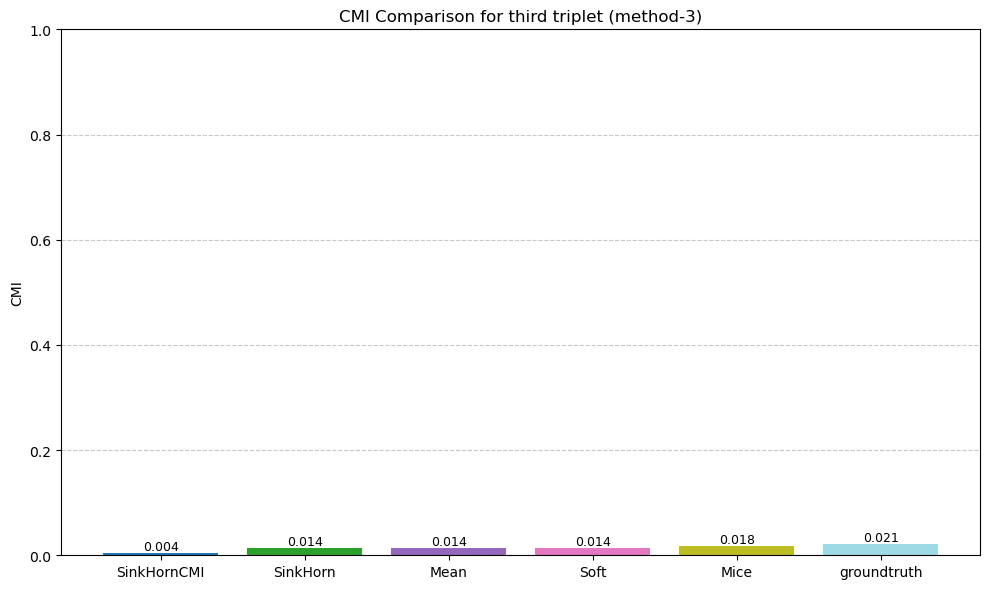

In [21]:
# Compute CMI for the third triplet using method-3 and compare its value across different imputation methods

# Filter for SinkHornCMI
sinkhorn_mask = (run1_results["imputation_method"] == "SinkHornCMI") & \
                (run1_results["train_triplet"] == 3) & \
                (run1_results["test_triplet"] == 3) & \
                (run1_results["train_cmi_type"] == 3) & \
                (run1_results["cmi_method"] == "method-3")

sinkhorn_cmi = run1_results[sinkhorn_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Filter for other methods (excluding SinkHornCMI and SinkHornCMI0)
other_mask = (~run1_results["imputation_method"].isin(["SinkHornCMI", "SinkHornCMI0"])) & \
             (run1_results["test_triplet"] == 3) & \
             (run1_results["cmi_method"] == "method-3")

other_cmi = run1_results[other_mask][["imputation_method", "cmi"]].set_index("imputation_method")

# Add groundtruth as a new row
groundtruth_value = run1_method3_original_cmi[2]
groundtruth_cmi = pd.DataFrame({"cmi": [groundtruth_value]}, index=["groundtruth"])

# Combine and sort
combined_cmi = pd.concat([sinkhorn_cmi, other_cmi, groundtruth_cmi])
sorted_cmi = combined_cmi.sort_values("cmi")
methods = sorted_cmi.index.tolist()
values = sorted_cmi["cmi"].values

# Generate distinct colors for each bar
cmap = plt.cm.get_cmap("tab20", len(values))
colors = [cmap(i) for i in range(len(values))]

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values, color=colors)

# Annotate each bar with its value
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                 ha='center', va='bottom', fontsize=9)

plt.ylabel("CMI")
plt.ylim(0, 1)
plt.title("CMI Comparison for third triplet (method-3)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()